# Lecture 26: Simulated Annealing - Benchmarking

---

```{note}
Lecture 25 ran Simulated Annealing on the Ackley function — the simplest possible setting, chosen so the lecture could focus entirely on turning pseudocode into code. This lecture moves to what this module actually cares about: real routing benchmarks from **TSPLIB**, the standard instance library the metaheuristics literature itself uses. It calibrates SA's cooling schedule on a small TSPLIB instance, then asks the question that actually matters in practice — does that calibration still work once you deploy on a substantially larger instance?
```

**Learning Objectives**

By the end of this notebook, you will be able to:
1. Represent a TSPLIB instance and implement a 2-opt neighbourhood for it.
2. Calibrate Simulated Annealing's cooling schedule on a small instance under a limited budget.
3. Evaluate whether a calibration found on a small instance still performs well on a substantially larger one, and explain why a cooling *rate* does not automatically rescale with problem size.

**Prerequisites**: Simulated Annealing - Algorithm (Lecture 25).

**Estimated time**: 50 minutes

---

## Why TSPLIB?

**TSPLIB** (Reinelt, 1991) is a public library of Traveling Salesman Problem instances — many drawn from real geographic data — used throughout the metaheuristics literature as a common, credible benchmark. Unlike the Chennai Metro Feeder Route (this module's own small illustrative instance, reserved for Lecture 33's capacitated capstone), TSPLIB instances come with **published optimal tour lengths**, so a result can be reported as a precise percentage gap from the true optimum rather than "seems reasonable."

This lecture uses two instances from the same family (Christofides & Eilon):
- **`eil51`** — 51 stops, optimal tour length **426** — small enough that a 10-seed calibration sweep stays fast.
- **`eil101`** — 101 stops, optimal tour length **629** — roughly twice the combinatorial scale, used only to test whether a calibration found on `eil51` still holds.

Since a solution is now a **tour** rather than a point in $\mathbb{R}^2$, this lecture also introduces the neighbourhood Lecture 25 never needed: **2-opt**, which reverses a randomly chosen segment of the tour — the same move this lecture's pre-restructuring predecessor used for the Chennai TSP, now meeting Simulated Annealing for the first time in this arc.

---

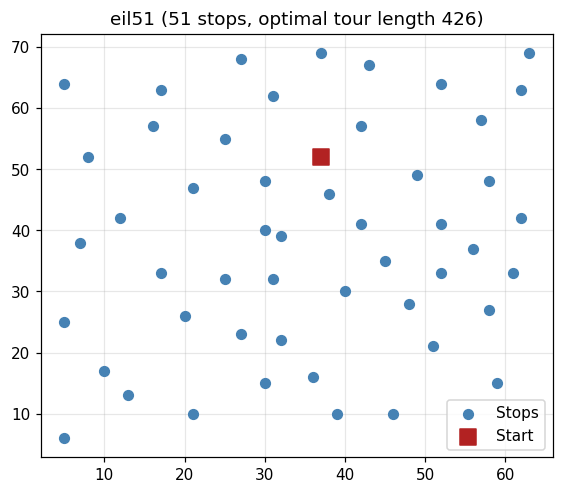

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

def sa(s_o, f, N, T_o, r, n=2000, t=1e-6):
    s, s_b, T = s_o, s_o, T_o
    F_b = [f(s_b)]
    k, e, converged = 0, float("inf"), False
    while not converged:
        s_n = N(s)
        d = f(s_n) - f(s)
        if d < 0 or random.uniform(0, 1) < np.exp(-d / T):
            s = s_n
        if f(s) < f(s_b):
            e = f(s_b) - f(s)
            s_b = s
        F_b.append(f(s_b))
        k += 1
        T = T_o * r ** k
        if k >= n or e <= t:
            converged = True
    return s_b, F_b

def N_2opt(s):
    """2-opt neighbourhood: reverse a random segment of the tour."""
    s = list(s)
    i, j = sorted(random.sample(range(len(s)), 2))
    return tuple(s[:i] + s[i:j + 1][::-1] + s[j + 1:])

# eil51: 51-city problem (Christofides/Eilon), TSPLIB, optimal = 426
EIL51 = [
    (37, 52), (49, 49), (52, 64), (20, 26), (40, 30), (21, 47), (17, 63), (31, 62), (52, 33), (51, 21),
    (42, 41), (31, 32), (5, 25), (12, 42), (36, 16), (52, 41), (27, 23), (17, 33), (13, 13), (57, 58),
    (62, 42), (42, 57), (16, 57), (8, 52), (7, 38), (27, 68), (30, 48), (43, 67), (58, 48), (58, 27),
    (37, 69), (38, 46), (46, 10), (61, 33), (62, 63), (63, 69), (32, 22), (45, 35), (59, 15), (5, 6),
    (10, 17), (21, 10), (5, 64), (30, 15), (39, 10), (32, 39), (25, 32), (25, 55), (48, 28), (56, 37),
    (30, 40),
]
EIL51_OPTIMAL = 426

def make_D(coords):
    n = len(coords)
    X = np.array([c[0] for c in coords], dtype=float)
    Y = np.array([c[1] for c in coords], dtype=float)
    D = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            D[i, j] = np.hypot(X[i] - X[j], Y[i] - Y[j])
    return D, X, Y

D51, X51, Y51 = make_D(EIL51)
customers51 = list(range(1, len(EIL51)))  # node 0 is the depot/start

def f_tsp(tour, D):
    c = D[0, tour[0]] + D[tour[-1], 0]
    for i in range(len(tour) - 1):
        c += D[tour[i], tour[i + 1]]
    return c

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(X51[1:], Y51[1:], c="steelblue", s=40, zorder=2, label="Stops")
ax.scatter(X51[0], Y51[0], c="firebrick", marker="s", s=100, zorder=3, label="Start")
ax.set_title("eil51 (51 stops, optimal tour length 426)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## Calibrating the Cooling Rate

Holding $T_o=20$ fixed and a tight budget of 1,000 iterations, only the cooling rate $r$ changes — averaged over 10 seeds per configuration, the same practice this module has used throughout.

In [2]:
def run_sa(r, T_o=20, n_iters=1000, n_seeds=10, D=D51, customers=customers51):
    results = []
    for seed in range(1, n_seeds + 1):
        random.seed(seed)
        np.random.seed(seed)
        s0 = tuple(random.sample(customers, len(customers)))
        random.seed(seed)
        np.random.seed(seed)
        s_b, F_b = sa(s0, lambda s: f_tsp(s, D), N_2opt, T_o=T_o, r=r, n=n_iters, t=1e-12)
        results.append(f_tsp(s_b, D))
    return np.array(results)

r_results = {}
for r in [0.9, 0.95, 0.97, 0.99, 0.999]:
    vals = run_sa(r)
    r_results[r] = vals
    gap = (vals.mean() - EIL51_OPTIMAL) / EIL51_OPTIMAL * 100
    print(f"r={r:<6} -> mean cost = {vals.mean():.2f}   gap from optimal = {gap:.1f}%")

r=0.9    -> mean cost = 677.48   gap from optimal = 59.0%
r=0.95   -> mean cost = 694.42   gap from optimal = 63.0%
r=0.97   -> mean cost = 590.16   gap from optimal = 38.5%
r=0.99   -> mean cost = 614.88   gap from optimal = 44.3%
r=0.999  -> mean cost = 844.57   gap from optimal = 98.3%


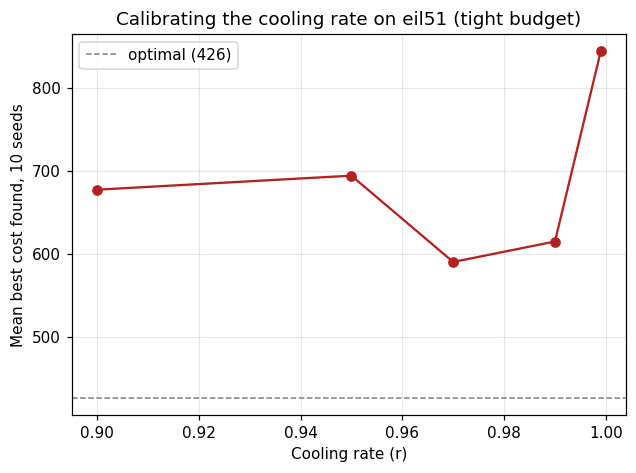

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))
ax.plot(list(r_results.keys()), [v.mean() for v in r_results.values()], "o-", color="firebrick")
ax.axhline(EIL51_OPTIMAL, color="gray", linestyle="--", linewidth=1, label="optimal (426)")
ax.set_xlabel("Cooling rate (r)")
ax.set_ylabel("Mean best cost found, 10 seeds")
ax.set_title("Calibrating the cooling rate on eil51 (tight budget)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

```{note}
$r=0.97$ is the clear best of the five, with both faster and slower cooling performing worse — the same interior sweet-spot shape this module has found for nearly every calibrated parameter. Too fast ($r \leq 0.95$) freezes the search before it has explored enough; too slow ($r \geq 0.99$) never finishes annealing within the 1,000-iteration budget, leaving the search still behaving like early-stage random exploration when the budget runs out.
```

---

## Benchmarking at Scale

`eil101` has roughly twice as many stops as `eil51`. Apply the calibrated schedule ($T_o=20$, $r=0.97$) **exactly as found**, at the same 1,000-iteration budget, and see what happens.

In [4]:
EIL101 = [
    (41, 49), (35, 17), (55, 45), (55, 20), (15, 30), (25, 30), (20, 50), (10, 43), (55, 60), (30, 60),
    (20, 65), (50, 35), (30, 25), (15, 10), (30, 5), (10, 20), (5, 30), (20, 40), (15, 60), (45, 65),
    (45, 20), (45, 10), (55, 5), (65, 35), (65, 20), (45, 30), (35, 40), (41, 37), (64, 42), (40, 60),
    (31, 52), (35, 69), (53, 52), (65, 55), (63, 65), (2, 60), (20, 20), (5, 5), (60, 12), (40, 25),
    (42, 7), (24, 12), (23, 3), (11, 14), (6, 38), (2, 48), (8, 56), (13, 52), (6, 68), (47, 47),
    (49, 58), (27, 43), (37, 31), (57, 29), (63, 23), (53, 12), (32, 12), (36, 26), (21, 24), (17, 34),
    (12, 24), (24, 58), (27, 69), (15, 77), (62, 77), (49, 73), (67, 5), (56, 39), (37, 47), (37, 56),
    (57, 68), (47, 16), (44, 17), (46, 13), (49, 11), (49, 42), (53, 43), (61, 52), (57, 48), (56, 37),
    (55, 54), (15, 47), (14, 37), (11, 31), (16, 22), (4, 18), (28, 18), (26, 52), (26, 35), (31, 67),
    (15, 19), (22, 22), (18, 24), (26, 27), (25, 24), (22, 27), (25, 21), (19, 21), (20, 26), (18, 18),
    (35, 35),
]
EIL101_OPTIMAL = 629
D101, X101, Y101 = make_D(EIL101)
customers101 = list(range(1, len(EIL101)))

random.seed(42)
np.random.seed(42)
s0 = tuple(random.sample(customers101, len(customers101)))
random.seed(42)
np.random.seed(42)
s_b_naive, F_b_naive = sa(s0, lambda s: f_tsp(s, D101), N_2opt, T_o=20, r=0.97, n=1000, t=1e-9)
cost_naive = f_tsp(s_b_naive, D101)
print(f"Naive transfer (T_o=20, r=0.97, n=1000): cost = {cost_naive:.2f}   "
      f"gap = {(cost_naive - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%")

Naive transfer (T_o=20, r=0.97, n=1000): cost = 1392.34   gap = 121.4%


That gap is large. Before concluding the calibration "doesn't transfer," check the obvious fix first: does simply running longer, at the *same* rate, help?

In [5]:
for n_iters in [3000, 10000]:
    random.seed(42)
    np.random.seed(42)
    s0 = tuple(random.sample(customers101, len(customers101)))
    random.seed(42)
    np.random.seed(42)
    s_b, F_b = sa(s0, lambda s: f_tsp(s, D101), N_2opt, T_o=20, r=0.97, n=n_iters, t=1e-9)
    cost = f_tsp(s_b, D101)
    print(f"r=0.97, n={n_iters:<6} -> cost = {cost:.2f}   gap = {(cost - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%   "
          f"(stopped after {len(F_b)-1} iterations)")

r=0.97, n=3000   -> cost = 1093.19   gap = 73.8%   (stopped after 2069 iterations)
r=0.97, n=10000  -> cost = 1093.19   gap = 73.8%   (stopped after 2069 iterations)


It plateaus almost immediately — $T_k = 20 \times 0.97^k$ is already effectively zero by iteration ~500, regardless of how many more iterations the search is allowed. Extra time alone cannot help once the temperature has already collapsed to zero; the schedule finished cooling long before the budget did. The cooling **rate** itself has to change, not just the iteration count.

In [6]:
random.seed(42)
np.random.seed(42)
s0 = tuple(random.sample(customers101, len(customers101)))
random.seed(42)
np.random.seed(42)
s_b_rescaled, F_b_rescaled = sa(s0, lambda s: f_tsp(s, D101), N_2opt, T_o=20, r=0.999, n=10000, t=1e-9)
cost_rescaled = f_tsp(s_b_rescaled, D101)
print(f"Rescaled (T_o=20, r=0.999, n=10000): cost = {cost_rescaled:.2f}   "
      f"gap = {(cost_rescaled - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%")

Rescaled (T_o=20, r=0.999, n=10000): cost = 733.62   gap = 16.6%


**Interpretation.** Slowing the cooling rate to $r=0.999$ and giving it a budget to match (10,000 iterations, matched to the *slower* schedule, not just "more") drops the gap from over 100% to well under 20%. Nothing about $r=0.97$ itself was wrong — it was calibrated correctly, for the budget it was calibrated on. What transferred to the larger instance was the **qualitative** lesson (don't cool too fast, don't cool too slow) — Lecture 25's step-size finding on Ackley made the same kind of point. What did **not** transfer was the literal numeric value of $r$: a rate tuned to finish cooling inside 1,000 iterations will always finish cooling inside roughly 1,000 iterations, no matter how large the instance or how much extra time you allow, because $r$ controls decay *per iteration*, not decay relative to problem difficulty.

> **Managerial insight**: a calibration performed on a small, cheap-to-experiment-with instance is not a number you can hand off unchanged to a production-scale problem — it is evidence about the *shape* of good behaviour (moderate cooling beats extremes) that still has to be re-scaled to the new problem's effective budget. Treating a calibrated parameter as a fixed constant, rather than as something coupled to the amount of search effort available, is a common and avoidable mistake.

---

## In-Class Exercise

### Exercise 1 — How Much Rescaling Is Enough?

Sweep $r \in \{0.995, 0.997, 0.999\}$ on `eil101` at a fixed budget of $n=5000$, and identify which comes closest to the rescaled result above at a fraction of its iteration budget.

In [7]:
for r in [0.995, 0.997, 0.999]:
    random.seed(42)
    np.random.seed(42)
    s0 = tuple(random.sample(customers101, len(customers101)))
    random.seed(42)
    np.random.seed(42)
    s_b, F_b = sa(s0, lambda s: f_tsp(s, D101), N_2opt, T_o=20, r=r, n=5000, t=1e-9)
    cost = f_tsp(s_b, D101)
    print(f"r={r:<6} n=5000 -> cost = {cost:.2f}   gap = {(cost - EIL101_OPTIMAL) / EIL101_OPTIMAL * 100:.1f}%")

r=0.995  n=5000 -> cost = 1142.37   gap = 81.6%
r=0.997  n=5000 -> cost = 878.60   gap = 39.7%
r=0.999  n=5000 -> cost = 825.35   gap = 31.2%


**Interpretation.** All three recover substantially compared to the naive $r=0.97$ transfer, but not uniformly close to the full-budget result: $r=0.999$ gets to a 31.2% gap at $n=5000$ — better than the others, but still well short of the 16.6% gap the same rate reached at $n=10000$. Half the budget buys real but partial recovery, confirming that the *direction* of the fix (slower cooling) matters even before the *amount* of extra budget is fully in place.

---

## Take-Away Exercises

### Exercise 1 — A Principled Rescaling Rule

Rather than guessing rescaled values by trial and error, propose a rule for how $r$ should change as a function of problem size (hint: consider how many iterations it takes $T_o r^k$ to fall below some small threshold, and how that iteration count might reasonably scale with the number of stops). Test your rule on `eil101`.

### Exercise 2 — A Third Instance

Find the coordinates for a third TSPLIB instance of a different size (e.g. `eil76`, roughly halfway between `eil51` and `eil101`), and check whether your Exercise 1 rescaling rule predicts its behaviour reasonably.

---

## Circling Back

- **Lecture 25 (Simulated Annealing: Algorithm)**: the step-size sensitivity found there (Ackley) and the cooling-rate sensitivity found here (TSPLIB) are the same underlying lesson, on two different problems.
- **Lecture 24 (Simulated Annealing: Motivation & Pseudocode)**: the hand-traced example's cooling schedule was a toy version of exactly the mechanism calibrated here at real scale.

## Moving Forward

- **Lecture 27 (Genetic Algorithm: Motivation & Pseudocode)**: introduces Lecture 23's second paradigm, population search.

---

## Further Reading

- Reinelt, G. (1991). "TSPLIB — A Traveling Salesman Problem Library." *ORSA Journal on Computing*, 3(4), 376-384.
- Christofides, N. and Eilon, S. (1969). "An Algorithm for the Vehicle-Dispatching Problem." *Operational Research Quarterly*, 20(3), 309-318 — origin of the `eil` instance family.
- Bertsimas, D. and Tsitsiklis, J. (1993). "Simulated Annealing." *Statistical Science*, 8(1), 10-15.